# app

10 - MobileNetV3 Evolutionary Search

Упрощённый эволюционный подбор гиперпараметров MobileNetV3 Small для CPU-friendly режима.

Цель ноутбука:

1. Проверить несколько конфигураций MobileNetV3 Small.
2. Подобрать параметры, влияющие на качество и скорость:
   - `image_size`;
   - `learning_rate`;
   - `weight_decay`;
   - `active_brazing_boost`;
   - уровень аугментаций.
3. Оценить качество по validation split.
4. Выбрать лучшую конфигурацию по fitness-функции.
5. Дообучить лучшего кандидата.
6. Оценить на test split.
7. Подготовить checkpoint для CPU latency benchmark.

В данном ноутбуке используется не полноценный NAS, а облегчённый эволюционный поиск по гиперпараметрам. Архитектура MobileNetV3 Small остаётся фиксированной.

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import time
import random
import warnings
from copy import deepcopy

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

## env

In [3]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')
EXPERIMENT_NAME = "mobilenet_evolutionary_search"

In [28]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [29]:
DATA = ROOT / "data" 

SPLITS_DIR = DATA / "annotations" / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

DATA_PROCESSED = DATA / 'processed'
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f'frames_{FPS}'
DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

DATA_RAW = DATA / 'raw'
DRIVE_DATA_RAW = DRIVE_FOLDER / DATA_RAW

assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

In [30]:
MODELS_DIR = ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" / EXPERIMENT_NAME
DRIVE_CHECKPOINTS_DIR = DRIVE_FOLDER / CHECKPOINTS_DIR

CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

In [31]:
REPORTS_ROOT = ROOT / "reports"
FIGURES_ROOT = ROOT / "reports" / "figures"
REPORTS_DIR = REPORTS_ROOT / EXPERIMENT_NAME
FIGURES_DIR = FIGURES_ROOT / EXPERIMENT_NAME

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [32]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ROI = {
    "x": 470,
    "y": 280,
    "w": 430,
    "h": 290,
}

# lib

In [33]:
def resolve_path(path_value: str) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path


def read_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def crop_roi(image: np.ndarray, roi: dict) -> np.ndarray:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    height, width = image.shape[:2]

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(width, x + w)
    y2 = min(height, y + h)

    if x1 >= x2 or y1 >= y2:
        raise ValueError(f"Invalid ROI for image shape {image.shape}: {roi}")

    return image[y1:y2, x1:x2]

# model

In [34]:
class BrazingStageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        roi: dict,
        transform=None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.roi = roi
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image_path = resolve_path(row["frame_path"])
        image = read_rgb_image(image_path)
        image = crop_roi(image, self.roi)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["stage_id"])

        metadata = {
            "video_id": row["video_id"],
            "frame_path": row["frame_path"],
            "timestamp_s": float(row["timestamp_s"]),
            "stage_name": row["stage_name"],
        }

        return image, label, metadata

# runtime

In [35]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

def stage_counts(df):
    return df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": stage_counts(train_df),
    "val": stage_counts(val_df),
    "test": stage_counts(test_df),
})

split_counts

train: (5755, 8)
val: (1091, 8)
test: (1732, 8)


,train,val,test
stage_name,,,
inactive_preparation,3552,734,1000
flux_activation,506,102,138
active_brazing,766,138,196
stabilization,931,117,398


## prepare

### transforms

In [36]:
def make_transforms(image_size: int, augmentation: str = "low"):
    if augmentation == "none":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    elif augmentation == "low":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.08,
                    contrast=0.08,
                    saturation=0.05,
                    hue=0.01,
                )
            ], p=0.4),
            transforms.RandomRotation(degrees=2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    elif augmentation == "medium":
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.10,
                    hue=0.02,
                )
            ], p=0.6),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))
            ], p=0.15),
            transforms.RandomRotation(degrees=3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        raise ValueError(f"Unknown augmentation: {augmentation}")

    eval_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    return train_transform, eval_transform

### dataloader

In [37]:
BATCH_SIZE = 32
NUM_WORKERS = 2

def make_dataloaders(image_size: int, augmentation: str = "low"):
    train_transform, eval_transform = make_transforms(
        image_size=image_size,
        augmentation=augmentation,
    )

    train_dataset = BrazingStageDataset(
        train_df,
        roi=ROI,
        transform=train_transform,
    )

    val_dataset = BrazingStageDataset(
        val_df,
        roi=ROI,
        transform=eval_transform,
    )

    test_dataset = BrazingStageDataset(
        test_df,
        roi=ROI,
        transform=eval_transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    return train_loader, val_loader, test_loader

### class weights

In [38]:
def make_class_weights(
    train_df: pd.DataFrame,
    active_brazing_boost: float = 1.0,
):
    train_counts = train_df["stage_id"].value_counts().sort_index()
    train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

    total = train_counts.sum()
    num_classes = len(train_counts)

    weights = total / (num_classes * train_counts.values)
    weights = weights.astype(np.float32)

    # active_brazing = class 2
    weights[2] *= active_brazing_boost

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


make_class_weights(train_df, active_brazing_boost=1.0)

tensor([0.4051, 2.8434, 1.8783, 1.5454], device='cuda:0')

### model factory

In [39]:
def create_mobilenet_v3_small(num_classes: int = 4, pretrained: bool = True):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_small(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model

### predict / evaluate helpers

In [40]:
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []
    all_metadata = []

    with torch.no_grad():
        for images, labels, metadata in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

            batch_size = len(labels)
            for i in range(batch_size):
                all_metadata.append({
                    "video_id": metadata["video_id"][i],
                    "frame_path": metadata["frame_path"][i],
                    "timestamp_s": float(metadata["timestamp_s"][i]),
                    "stage_name": metadata["stage_name"][i],
                })

    probs_np = torch.cat(all_probs, dim=0).numpy()

    pred_df = pd.DataFrame(all_metadata)
    pred_df["stage_id"] = all_targets
    pred_df["pred_stage_id"] = all_preds
    pred_df["pred_stage_name"] = pred_df["pred_stage_id"].map(ID_TO_STAGE)

    for class_id, stage_name in ID_TO_STAGE.items():
        pred_df[f"prob_{stage_name}"] = probs_np[:, class_id]

    return pred_df


def evaluate_predictions(pred_df: pd.DataFrame, title: str):
    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "active_brazing_precision": report["active_brazing"]["precision"],
        "active_brazing_recall": report["active_brazing"]["recall"],
        "active_brazing_f1": report["active_brazing"]["f1-score"],
        "confusion_matrix": cm.tolist(),
    }

### train helpers

In [41]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def train_candidate(
    candidate: dict,
    epochs: int = 6,
):
    run_name = candidate["run_name"]

    image_size = int(candidate["image_size"])
    lr = float(candidate["lr"])
    weight_decay = float(candidate["weight_decay"])
    active_brazing_boost = float(candidate["active_brazing_boost"])
    augmentation = candidate["augmentation"]

    train_loader, val_loader, test_loader = make_dataloaders(
        image_size=image_size,
        augmentation=augmentation,
    )

    model = create_mobilenet_v3_small(num_classes=4, pretrained=True).to(DEVICE)

    class_weights = make_class_weights(
        train_df,
        active_brazing_boost=active_brazing_boost,
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    best_val_macro_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        val_pred_df = predict_loader(model, val_loader)
        y_val_true = val_pred_df["stage_id"].to_numpy()
        y_val_pred = val_pred_df["pred_stage_id"].to_numpy()

        val_report = classification_report(
            y_val_true,
            y_val_pred,
            labels=[0, 1, 2, 3],
            target_names=STAGE_ORDER,
            output_dict=True,
            zero_division=0,
        )

        val_active_f1 = val_report["active_brazing"]["f1-score"]
        val_active_recall = val_report["active_brazing"]["recall"]

        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "run_name": run_name,
            "image_size": image_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "active_brazing_boost": active_brazing_boost,
            "augmentation": augmentation,
            "epoch_time_s": epoch_time,
            "val_active_brazing_f1": val_active_f1,
            "val_active_brazing_recall": val_active_recall,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        print(
            f"[{run_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_active_f1={val_active_f1:.4f} "
            f"val_active_recall={val_active_recall:.4f} | "
            f"{epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = {
                "run_name": run_name,
                "model_name": "mobilenet_v3_small",
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "val_active_brazing_f1": val_active_f1,
                "val_active_brazing_recall": val_active_recall,
                "candidate": deepcopy(candidate),
                "roi": ROI,
                "image_size": image_size,
                "stage_order": STAGE_ORDER,
                "fps": FPS,
            }

    history_df = pd.DataFrame(history)

    checkpoint_path = CHECKPOINTS_DIR / f"{run_name}_best.pt"
    torch.save(best_state, checkpoint_path)

    history_path = REPORTS_DIR / f"{run_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    model.load_state_dict(best_state["model_state_dict"])

    result = {
        "run_name": run_name,
        "candidate": candidate,
        "model": model,
        "history": history_df,
        "checkpoint": checkpoint_path,
        "test_loader": test_loader,
        "best_state": best_state,
    }

    return result

## evolution

In [42]:
SEARCH_SPACE = {
    "image_size": [128, 160, 192, 224],
    "lr": [1e-4, 3e-4],
    "weight_decay": [1e-5, 1e-4, 3e-4],
    "active_brazing_boost": [1.0, 1.2, 1.5, 2.0],
    "augmentation": ["low", "medium"],
}

### candidate

In [43]:
def random_candidate(run_idx: int) -> dict:
    return {
        "run_name": f"mobilenet_evo_{run_idx:03d}",
        "image_size": random.choice(SEARCH_SPACE["image_size"]),
        "lr": random.choice(SEARCH_SPACE["lr"]),
        "weight_decay": random.choice(SEARCH_SPACE["weight_decay"]),
        "active_brazing_boost": random.choice(SEARCH_SPACE["active_brazing_boost"]),
        "augmentation": random.choice(SEARCH_SPACE["augmentation"]),
    }


def mutate_candidate(parent: dict, run_idx: int, mutation_prob: float = 0.35) -> dict:
    child = deepcopy(parent)
    child["run_name"] = f"mobilenet_evo_{run_idx:03d}"

    for key in ["image_size", "lr", "weight_decay", "active_brazing_boost", "augmentation"]:
        if random.random() < mutation_prob:
            child[key] = random.choice(SEARCH_SPACE[key])

    return child


def crossover_candidate(parent_a: dict, parent_b: dict, run_idx: int) -> dict:
    child = {"run_name": f"mobilenet_evo_{run_idx:03d}"}

    for key in ["image_size", "lr", "weight_decay", "active_brazing_boost", "augmentation"]:
        child[key] = random.choice([parent_a[key], parent_b[key]])

    return child

### fitness

In [44]:
def estimate_latency_penalty(image_size: int) -> float:
    """
    Approximate latency penalty.

    MobileNetV3 224x224 already passed CPU p95 < 50 ms,
    so penalty is mostly zero for studied sizes.

    Kept for formal evolutionary fitness structure.
    """
    if image_size <= 224:
        return 0.0

    return 1.0


def compute_fitness(row: pd.Series) -> float:
    latency_penalty = estimate_latency_penalty(int(row["image_size"]))

    return (
        float(row["best_val_macro_f1"])
        + 0.30 * float(row["best_val_active_brazing_f1"])
        - 0.10 * latency_penalty
    )

### initial population

In [45]:
INITIAL_POPULATION_SIZE = 8
NUM_PARENTS = 3
NUM_MUTATIONS = 4
NUM_CROSSOVERS = 4
MUTATION_PROB = 0.45
CROSSOVER_MUTATION_PROB = 0.25

In [49]:
population = [
    random_candidate(run_idx=i)
    for i in range(INITIAL_POPULATION_SIZE)
]

pd.DataFrame(population)

,run_name,image_size,lr,weight_decay,active_brazing_boost,augmentation
0,mobilenet_evo_000,224,0.0001,0.00030,1.5,low
1,mobilenet_evo_001,128,0.0003,0.00030,1.2,low
2,mobilenet_evo_002,192,0.0001,0.00030,1.0,medium
3,mobilenet_evo_003,224,0.0001,0.00001,1.5,medium
4,mobilenet_evo_004,160,0.0001,0.00001,1.0,low
5,mobilenet_evo_005,224,0.0001,0.00030,1.2,low
6,mobilenet_evo_006,224,0.0001,0.00010,2.0,low
7,mobilenet_evo_007,160,0.0003,0.00010,1.5,medium


### train initial population

In [50]:
EVOLUTION_RESULTS = []
run_counter = INITIAL_POPULATION_SIZE

for candidate in population:
    result = train_candidate(candidate, epochs=8)

    history = result["history"]
    best_row = history.loc[history["val_macro_f1"].idxmax()]

    result_row = {
        **candidate,
        "best_val_macro_f1": best_row["val_macro_f1"],
        "best_val_accuracy": best_row["val_accuracy"],
        "best_val_active_brazing_f1": best_row["val_active_brazing_f1"],
        "best_val_active_brazing_recall": best_row["val_active_brazing_recall"],
        "checkpoint": str(result["checkpoint"]),
    }

    EVOLUTION_RESULTS.append(result_row)

[mobilenet_evo_000] Epoch 01/8 | val_f1=0.6370 val_acc=0.7599 val_active_f1=0.6618 val_active_recall=0.6594 | 20.8s
[mobilenet_evo_000] Epoch 02/8 | val_f1=0.8428 val_acc=0.9212 val_active_f1=0.7578 val_active_recall=0.8841 | 21.4s
[mobilenet_evo_000] Epoch 03/8 | val_f1=0.8607 val_acc=0.9358 val_active_f1=0.7660 val_active_recall=0.7826 | 20.8s
[mobilenet_evo_000] Epoch 04/8 | val_f1=0.8578 val_acc=0.9239 val_active_f1=0.7571 val_active_recall=0.8696 | 20.9s
[mobilenet_evo_000] Epoch 05/8 | val_f1=0.7907 val_acc=0.8836 val_active_f1=0.6648 val_active_recall=0.8551 | 21.4s
[mobilenet_evo_000] Epoch 06/8 | val_f1=0.8508 val_acc=0.9166 val_active_f1=0.7640 val_active_recall=0.8913 | 21.0s
[mobilenet_evo_000] Epoch 07/8 | val_f1=0.8466 val_acc=0.9138 val_active_f1=0.7622 val_active_recall=0.7899 | 20.8s
[mobilenet_evo_000] Epoch 08/8 | val_f1=0.8571 val_acc=0.9322 val_active_f1=0.8051 val_active_recall=0.9130 | 20.9s
[mobilenet_evo_001] Epoch 01/8 | val_f1=0.5717 val_acc=0.7892 val_active

### select parents

In [51]:
evolution_df = pd.DataFrame(EVOLUTION_RESULTS)
evolution_df["fitness"] = evolution_df.apply(compute_fitness, axis=1)

evolution_df = evolution_df.sort_values("fitness", ascending=False)
evolution_df

,run_name,image_size,lr,weight_decay,active_brazing_boost,augmentation,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint,fitness
5,mobilenet_evo_005,224,0.0001,0.00030,1.2,low,0.927428,0.960587,0.910448,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.200562
2,mobilenet_evo_002,192,0.0001,0.00030,1.0,medium,0.914515,0.959670,0.895105,0.927536,models/checkpoints/mobilenet_evolutionary_sear...,1.183046
1,mobilenet_evo_001,128,0.0003,0.00030,1.2,low,0.863541,0.929423,0.824000,0.746377,models/checkpoints/mobilenet_evolutionary_sear...,1.110741
6,mobilenet_evo_006,224,0.0001,0.00010,2.0,low,0.853333,0.930339,0.800000,0.782609,models/checkpoints/mobilenet_evolutionary_sear...,1.093333
0,mobilenet_evo_000,224,0.0001,0.00030,1.5,low,0.860677,0.935839,0.765957,0.782609,models/checkpoints/mobilenet_evolutionary_sear...,1.090464
4,mobilenet_evo_004,160,0.0001,0.00001,1.0,low,0.849033,0.924840,0.791367,0.797101,models/checkpoints/mobilenet_evolutionary_sear...,1.086443
3,mobilenet_evo_003,224,0.0001,0.00001,1.5,medium,0.831464,0.917507,0.784566,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.066833
7,mobilenet_evo_007,160,0.0003,0.00010,1.5,medium,0.739483,0.829514,0.540682,0.746377,models/checkpoints/mobilenet_evolutionary_sear...,0.901688


In [54]:
top_parents = evolution_df.head(NUM_PARENTS).to_dict("records")
top_parents

[{'run_name': 'mobilenet_evo_005',
  'image_size': 224,
  'lr': 0.0001,
  'weight_decay': 0.0003,
  'active_brazing_boost': 1.2,
  'augmentation': 'low',
  'best_val_macro_f1': 0.9274278441401353,
  'best_val_accuracy': 0.9605866177818515,
  'best_val_active_brazing_f1': 0.9104477611940298,
  'best_val_active_brazing_recall': 0.8840579710144928,
  'checkpoint': 'models/checkpoints/mobilenet_evolutionary_search/mobilenet_evo_005_best.pt',
  'fitness': 1.2005621724983442},
 {'run_name': 'mobilenet_evo_002',
  'image_size': 192,
  'lr': 0.0001,
  'weight_decay': 0.0003,
  'active_brazing_boost': 1.0,
  'augmentation': 'medium',
  'best_val_macro_f1': 0.9145147007987792,
  'best_val_accuracy': 0.9596700274977086,
  'best_val_active_brazing_f1': 0.8951048951048951,
  'best_val_active_brazing_recall': 0.927536231884058,
  'checkpoint': 'models/checkpoints/mobilenet_evolutionary_search/mobilenet_evo_002_best.pt',
  'fitness': 1.1830461693302476},
 {'run_name': 'mobilenet_evo_001',
  'image_si

### create next generation

In [53]:
next_generation = []

# Mutations from top parents
for _ in range(NUM_MUTATIONS):
    parent = random.choice(top_parents)

    child = mutate_candidate(
        parent,
        run_idx=run_counter,
        mutation_prob=MUTATION_PROB,
    )

    run_counter += 1
    next_generation.append(child)

# Crossovers between top parents
for _ in range(NUM_CROSSOVERS):
    parent_a, parent_b = random.sample(top_parents, 2)

    child = crossover_candidate(
        parent_a,
        parent_b,
        run_idx=run_counter,
    )
    run_counter += 1

    child = mutate_candidate(
        child,
        run_idx=run_counter,
        mutation_prob=CROSSOVER_MUTATION_PROB,
    )
    run_counter += 1

    next_generation.append(child)

next_generation_df = pd.DataFrame(next_generation)
next_generation_df

,run_name,image_size,lr,weight_decay,active_brazing_boost,augmentation,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint,fitness
0,mobilenet_evo_008,128,0.0001,0.00030,1.2,low,0.863541,0.929423,0.824000,0.746377,models/checkpoints/mobilenet_evolutionary_sear...,1.110741
1,mobilenet_evo_009,128,0.0001,0.00030,1.2,medium,0.927428,0.960587,0.910448,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.200562
2,mobilenet_evo_010,224,0.0001,0.00030,1.2,medium,0.927428,0.960587,0.910448,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.200562
3,mobilenet_evo_011,128,0.0001,0.00010,1.0,medium,0.914515,0.959670,0.895105,0.927536,models/checkpoints/mobilenet_evolutionary_sear...,1.183046
4,mobilenet_evo_013,224,0.0001,0.00030,1.0,low,NaN,NaN,NaN,NaN,NaN,NaN
5,mobilenet_evo_015,128,0.0003,0.00030,1.2,low,NaN,NaN,NaN,NaN,NaN,NaN
6,mobilenet_evo_017,160,0.0003,0.00030,1.2,medium,NaN,NaN,NaN,NaN,NaN,NaN
7,mobilenet_evo_019,128,0.0001,0.00001,1.2,low,NaN,NaN,NaN,NaN,NaN,NaN


### train next generation

In [55]:
for candidate in next_generation:
    result = train_candidate(candidate, epochs=8)

    history = result["history"]
    best_row = history.loc[history["val_macro_f1"].idxmax()]

    result_row = {
        **candidate,
        "best_val_macro_f1": best_row["val_macro_f1"],
        "best_val_accuracy": best_row["val_accuracy"],
        "best_val_active_brazing_f1": best_row["val_active_brazing_f1"],
        "best_val_active_brazing_recall": best_row["val_active_brazing_recall"],
        "checkpoint": str(result["checkpoint"]),
    }

    EVOLUTION_RESULTS.append(result_row)

[mobilenet_evo_008] Epoch 01/8 | val_f1=0.5799 val_acc=0.8203 val_active_f1=0.6448 val_active_recall=0.8551 | 18.0s
[mobilenet_evo_008] Epoch 02/8 | val_f1=0.7735 val_acc=0.8973 val_active_f1=0.7009 val_active_recall=0.8406 | 17.7s
[mobilenet_evo_008] Epoch 03/8 | val_f1=0.8704 val_acc=0.9349 val_active_f1=0.8213 val_active_recall=0.7826 | 17.7s
[mobilenet_evo_008] Epoch 04/8 | val_f1=0.8774 val_acc=0.9349 val_active_f1=0.8550 val_active_recall=0.8333 | 17.7s
[mobilenet_evo_008] Epoch 05/8 | val_f1=0.8597 val_acc=0.9303 val_active_f1=0.8151 val_active_recall=0.7826 | 17.6s
[mobilenet_evo_008] Epoch 06/8 | val_f1=0.8762 val_acc=0.9358 val_active_f1=0.8633 val_active_recall=0.8696 | 17.7s
[mobilenet_evo_008] Epoch 07/8 | val_f1=0.7484 val_acc=0.9065 val_active_f1=0.7667 val_active_recall=1.0000 | 17.8s
[mobilenet_evo_008] Epoch 08/8 | val_f1=0.8662 val_acc=0.9358 val_active_f1=0.8571 val_active_recall=1.0000 | 17.6s
[mobilenet_evo_009] Epoch 01/8 | val_f1=0.5660 val_acc=0.8048 val_active

### final evolutionary ranking

In [56]:
evolution_df = pd.DataFrame(EVOLUTION_RESULTS)
evolution_df["fitness"] = evolution_df.apply(compute_fitness, axis=1)

evolution_df = evolution_df.sort_values("fitness", ascending=False).reset_index(drop=True)

evolution_df

,run_name,image_size,lr,weight_decay,active_brazing_boost,augmentation,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint,fitness
0,mobilenet_evo_005,224,0.0001,0.00030,1.2,low,0.927428,0.960587,0.910448,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.200562
1,mobilenet_evo_002,192,0.0001,0.00030,1.0,medium,0.914515,0.959670,0.895105,0.927536,models/checkpoints/mobilenet_evolutionary_sear...,1.183046
2,mobilenet_evo_015,128,0.0003,0.00030,1.2,low,0.887678,0.941338,0.927757,0.884058,models/checkpoints/mobilenet_evolutionary_sear...,1.166005
3,mobilenet_evo_009,128,0.0001,0.00030,1.2,medium,0.896755,0.949588,0.874525,0.833333,models/checkpoints/mobilenet_evolutionary_sear...,1.159113
4,mobilenet_evo_008,128,0.0001,0.00030,1.2,low,0.877371,0.934922,0.855019,0.833333,models/checkpoints/mobilenet_evolutionary_sear...,1.133877
5,mobilenet_evo_013,224,0.0001,0.00030,1.0,low,0.884188,0.938588,0.822581,0.739130,models/checkpoints/mobilenet_evolutionary_sear...,1.130962
6,mobilenet_evo_019,128,0.0001,0.00001,1.2,low,0.874890,0.939505,0.837037,0.818841,models/checkpoints/mobilenet_evolutionary_sear...,1.126001
7,mobilenet_evo_001,128,0.0003,0.00030,1.2,low,0.863541,0.929423,0.824000,0.746377,models/checkpoints/mobilenet_evolutionary_sear...,1.110741
8,mobilenet_evo_006,224,0.0001,0.00010,2.0,low,0.853333,0.930339,0.800000,0.782609,models/checkpoints/mobilenet_evolutionary_sear...,1.093333
9,mobilenet_evo_011,128,0.0001,0.00010,1.0,medium,0.839958,0.923923,0.841424,0.942029,models/checkpoints/mobilenet_evolutionary_sear...,1.092385


In [57]:
evolution_df.to_csv(
    REPORTS_DIR / "mobilenet_evolutionary_search_results.csv",
    index=False,
)

## best candidate

### top-1

In [58]:
best_candidate = evolution_df.iloc[0].to_dict()

best_candidate_config = {
    "run_name": "mobilenet_evo_best_finetuned",
    "image_size": int(best_candidate["image_size"]),
    "lr": float(best_candidate["lr"]),
    "weight_decay": float(best_candidate["weight_decay"]),
    "active_brazing_boost": float(best_candidate["active_brazing_boost"]),
    "augmentation": best_candidate["augmentation"],
}

best_candidate_config

{'run_name': 'mobilenet_evo_best_finetuned',
 'image_size': 224,
 'lr': 0.0001,
 'weight_decay': 0.0003,
 'active_brazing_boost': 1.2,
 'augmentation': 'low'}

In [59]:
best_result = train_candidate(
    best_candidate_config,
    epochs=24,
)

best_history = best_result["history"]
best_checkpoint = best_result["checkpoint"]
best_model = best_result["model"]
best_test_loader = best_result["test_loader"]

best_checkpoint

[mobilenet_evo_best_finetuned] Epoch 01/24 | val_f1=0.3165 val_acc=0.7030 val_active_f1=0.3030 val_active_recall=0.1812 | 20.9s
[mobilenet_evo_best_finetuned] Epoch 02/24 | val_f1=0.8336 val_acc=0.9111 val_active_f1=0.7500 val_active_recall=0.6522 | 21.0s
[mobilenet_evo_best_finetuned] Epoch 03/24 | val_f1=0.8676 val_acc=0.9413 val_active_f1=0.7925 val_active_recall=0.7609 | 20.9s
[mobilenet_evo_best_finetuned] Epoch 04/24 | val_f1=0.8437 val_acc=0.9303 val_active_f1=0.8013 val_active_recall=0.9203 | 21.0s
[mobilenet_evo_best_finetuned] Epoch 05/24 | val_f1=0.8496 val_acc=0.9340 val_active_f1=0.7785 val_active_recall=0.8406 | 21.0s
[mobilenet_evo_best_finetuned] Epoch 06/24 | val_f1=0.8111 val_acc=0.9028 val_active_f1=0.7338 val_active_recall=0.8188 | 21.0s
[mobilenet_evo_best_finetuned] Epoch 07/24 | val_f1=0.7716 val_acc=0.8928 val_active_f1=0.6921 val_active_recall=0.9203 | 20.8s
[mobilenet_evo_best_finetuned] Epoch 08/24 | val_f1=0.8071 val_acc=0.9093 val_active_f1=0.7500 val_activ

PosixPath('models/checkpoints/mobilenet_evolutionary_search/mobilenet_evo_best_finetuned_best.pt')

### top-2

In [62]:
best_candidate_2 = evolution_df.iloc[1].to_dict()

best_candidate_config_2 = {
    "run_name": "mobilenet_evo_best_finetuned_2",
    "image_size": int(best_candidate_2["image_size"]),
    "lr": float(best_candidate_2["lr"]),
    "weight_decay": float(best_candidate_2["weight_decay"]),
    "active_brazing_boost": float(best_candidate_2["active_brazing_boost"]),
    "augmentation": best_candidate_2["augmentation"],
}

best_candidate_config_2

{'run_name': 'mobilenet_evo_best_finetuned_2',
 'image_size': 192,
 'lr': 0.0001,
 'weight_decay': 0.0003,
 'active_brazing_boost': 1.0,
 'augmentation': 'medium'}

In [63]:
best_result_2 = train_candidate(
    best_candidate_config_2,
    epochs=24,
)

best_history_2 = best_result_2["history"]
best_checkpoint_2 = best_result_2["checkpoint"]
best_model_2 = best_result_2["model"]
best_test_loader_2 = best_result_2["test_loader"]

best_checkpoint_2

[mobilenet_evo_best_finetuned_2] Epoch 01/24 | val_f1=0.5927 val_acc=0.7919 val_active_f1=0.3750 val_active_recall=0.2391 | 21.0s
[mobilenet_evo_best_finetuned_2] Epoch 02/24 | val_f1=0.8480 val_acc=0.9221 val_active_f1=0.7477 val_active_recall=0.6014 | 21.0s
[mobilenet_evo_best_finetuned_2] Epoch 03/24 | val_f1=0.8713 val_acc=0.9294 val_active_f1=0.8725 val_active_recall=0.9420 | 21.0s
[mobilenet_evo_best_finetuned_2] Epoch 04/24 | val_f1=0.9061 val_acc=0.9551 val_active_f1=0.8920 val_active_recall=0.9275 | 20.8s
[mobilenet_evo_best_finetuned_2] Epoch 05/24 | val_f1=0.8407 val_acc=0.9285 val_active_f1=0.7965 val_active_recall=0.9783 | 21.1s
[mobilenet_evo_best_finetuned_2] Epoch 06/24 | val_f1=0.9160 val_acc=0.9597 val_active_f1=0.9104 val_active_recall=0.9203 | 21.3s
[mobilenet_evo_best_finetuned_2] Epoch 07/24 | val_f1=0.8912 val_acc=0.9496 val_active_f1=0.8562 val_active_recall=0.9275 | 21.0s
[mobilenet_evo_best_finetuned_2] Epoch 08/24 | val_f1=0.8804 val_acc=0.9459 val_active_f1=

PosixPath('models/checkpoints/mobilenet_evolutionary_search/mobilenet_evo_best_finetuned_2_best.pt')

### top-3

In [64]:
best_candidate_3 = evolution_df.iloc[2].to_dict()

best_candidate_config_3 = {
    "run_name": "mobilenet_evo_best_finetuned_3",
    "image_size": int(best_candidate_3["image_size"]),
    "lr": float(best_candidate_3["lr"]),
    "weight_decay": float(best_candidate_3["weight_decay"]),
    "active_brazing_boost": float(best_candidate_3["active_brazing_boost"]),
    "augmentation": best_candidate_3["augmentation"],
}

best_candidate_config_3

{'run_name': 'mobilenet_evo_best_finetuned_3',
 'image_size': 128,
 'lr': 0.0003,
 'weight_decay': 0.0003,
 'active_brazing_boost': 1.2,
 'augmentation': 'low'}

In [65]:
best_result_3 = train_candidate(
    best_candidate_config_3,
    epochs=24,
)

best_history_3 = best_result_3["history"]
best_checkpoint_3 = best_result_3["checkpoint"]
best_model_3 = best_result_3["model"]
best_test_loader_3 = best_result_3["test_loader"]

best_checkpoint_3

[mobilenet_evo_best_finetuned_3] Epoch 01/24 | val_f1=0.7880 val_acc=0.8983 val_active_f1=0.8655 val_active_recall=0.8623 | 17.9s
[mobilenet_evo_best_finetuned_3] Epoch 02/24 | val_f1=0.6710 val_acc=0.8772 val_active_f1=0.7302 val_active_recall=1.0000 | 17.8s
[mobilenet_evo_best_finetuned_3] Epoch 03/24 | val_f1=0.8643 val_acc=0.9340 val_active_f1=0.8485 val_active_recall=0.9130 | 17.6s
[mobilenet_evo_best_finetuned_3] Epoch 04/24 | val_f1=0.7369 val_acc=0.8662 val_active_f1=0.7500 val_active_recall=0.9565 | 17.9s
[mobilenet_evo_best_finetuned_3] Epoch 05/24 | val_f1=0.7383 val_acc=0.9038 val_active_f1=0.7443 val_active_recall=0.9493 | 17.8s
[mobilenet_evo_best_finetuned_3] Epoch 06/24 | val_f1=0.8117 val_acc=0.9230 val_active_f1=0.7917 val_active_recall=0.9638 | 17.8s
[mobilenet_evo_best_finetuned_3] Epoch 07/24 | val_f1=0.8018 val_acc=0.9221 val_active_f1=0.8280 val_active_recall=0.9420 | 17.8s
[mobilenet_evo_best_finetuned_3] Epoch 08/24 | val_f1=0.7602 val_acc=0.9056 val_active_f1=

PosixPath('models/checkpoints/mobilenet_evolutionary_search/mobilenet_evo_best_finetuned_3_best.pt')

### plot best history

In [85]:
def plot_history(history_df, run_name):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
    plt.plot(
        history_df["epoch"],
        history_df["val_active_brazing_f1"],
        label="val_active_brazing_f1",
        linestyle="--",
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_active_brazing_recall"],
        label="val_active_brazing_recall",
        linestyle="--",
    )

    plt.title(f"Training curves — {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{run_name}_training_curves.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

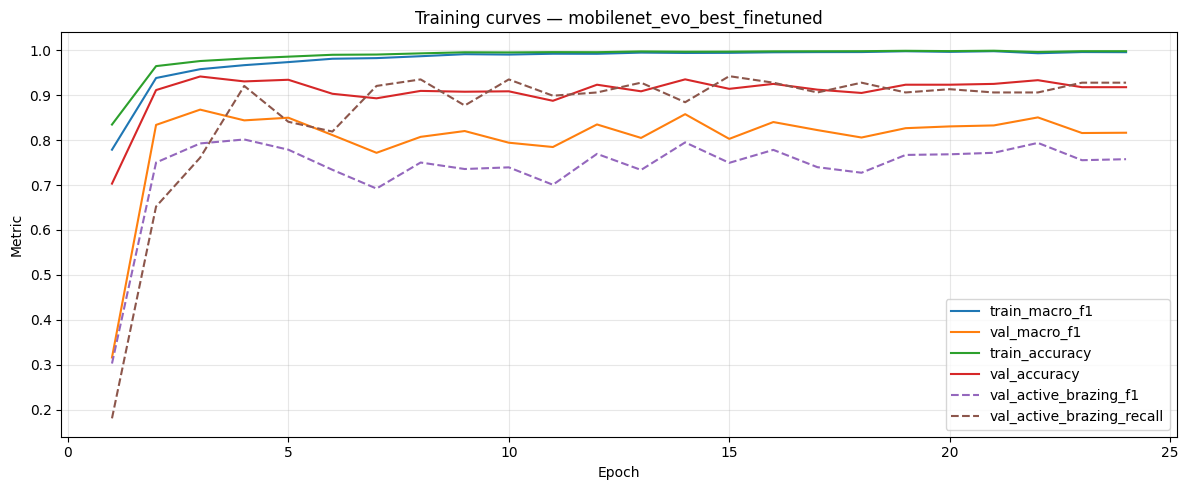

In [86]:
plot_history(best_history, "mobilenet_evo_best_finetuned")

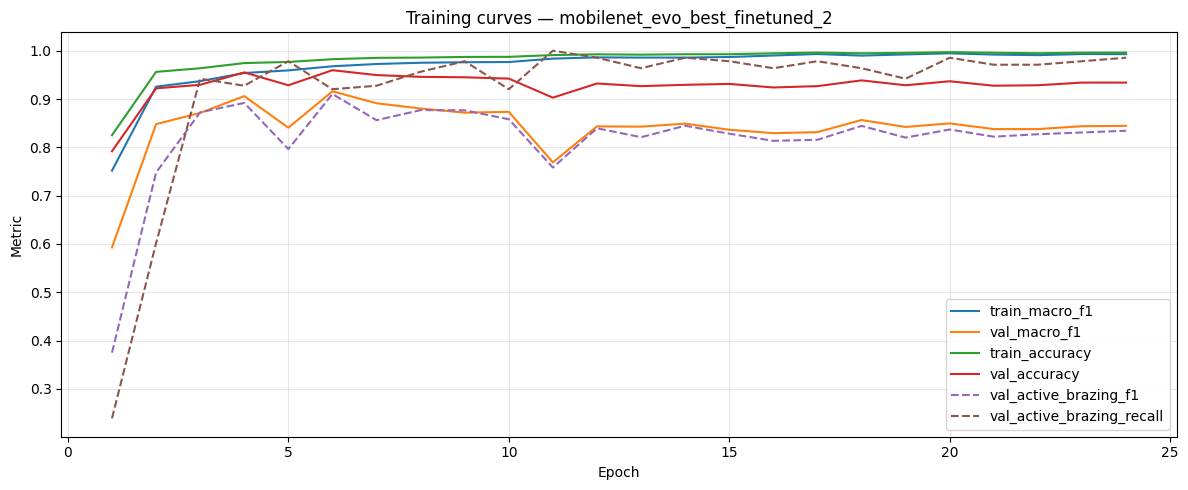

In [87]:
plot_history(best_history_2, "mobilenet_evo_best_finetuned_2")

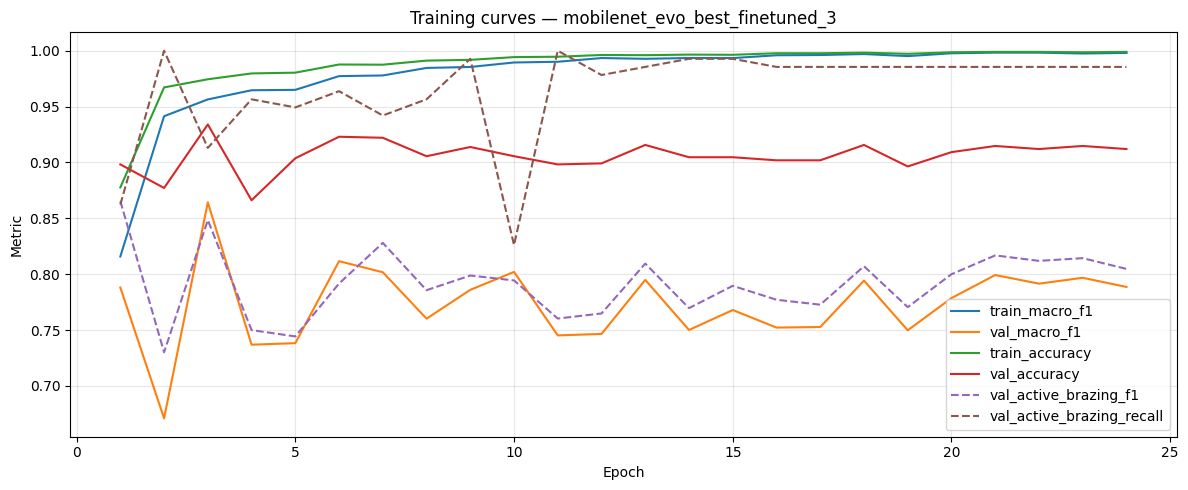

In [88]:
plot_history(best_history_3, "mobilenet_evo_best_finetuned_3")

### test

In [89]:
def evaluate_best_candidate(
    model,
    test_loader,
    candidate_config: dict,
    checkpoint_path: Path,
    candidate_name: str,
):
    pred_df = predict_loader(model, test_loader)

    test_metrics = evaluate_predictions(
        pred_df,
        title=f"Test — MobileNetV3 Small evolutionary {candidate_name}",
    )

    pred_path = REPORTS_DIR / f"mobilenet_evo_{candidate_name}_test_predictions.csv"
    metrics_path = REPORTS_DIR / f"mobilenet_evo_{candidate_name}_test_metrics.json"

    pred_df.to_csv(pred_path, index=False)

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "candidate_name": candidate_name,
                "best_candidate_config": candidate_config,
                "checkpoint": str(checkpoint_path),
                "test_metrics": test_metrics,
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "candidate_name": candidate_name,
        "image_size": candidate_config["image_size"],
        "lr": candidate_config["lr"],
        "weight_decay": candidate_config["weight_decay"],
        "active_brazing_boost": candidate_config["active_brazing_boost"],
        "augmentation": candidate_config["augmentation"],
        **{k: v for k, v in test_metrics.items() if k != "confusion_matrix"},
        "checkpoint": str(checkpoint_path),
        "predictions_path": str(pred_path),
        "metrics_path": str(metrics_path),
    }, pred_df

Test — MobileNetV3 Small evolutionary best_1
--------------------------------------------------------------------------------
accuracy:    0.8822
macro_f1:    0.7820
weighted_f1: 0.8803

                      precision    recall  f1-score   support

inactive_preparation     0.9915    0.9380    0.9640      1000
     flux_activation     0.5869    0.9058    0.7123       138
      active_brazing     0.7563    0.4592    0.5714       196
       stabilization     0.8260    0.9422    0.8803       398

            accuracy                         0.8822      1732
           macro avg     0.7902    0.8113    0.7820      1732
        weighted avg     0.8946    0.8822    0.8803      1732



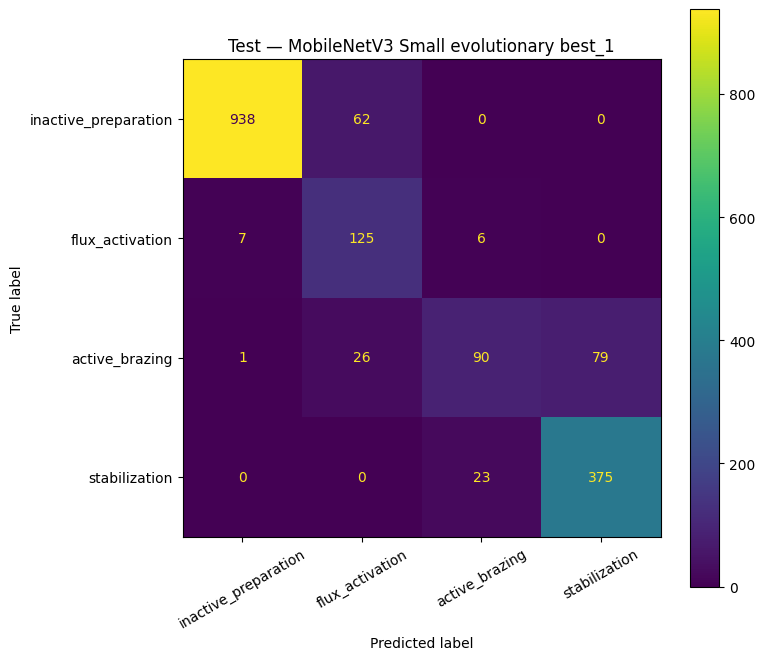

In [90]:
top_candidate_results = []
top_candidate_predictions = {}

result_1, pred_1 = evaluate_best_candidate(
    model=best_model,
    test_loader=best_test_loader,
    candidate_config=best_candidate_config,
    checkpoint_path=best_checkpoint,
    candidate_name="best_1",
)

top_candidate_results.append(result_1)
top_candidate_predictions["best_1"] = pred_1

Test — MobileNetV3 Small evolutionary best_2
--------------------------------------------------------------------------------
accuracy:    0.8274
macro_f1:    0.7044
weighted_f1: 0.8397

                      precision    recall  f1-score   support

inactive_preparation     0.9903    0.9160    0.9517      1000
     flux_activation     0.4185    0.8188    0.5539       138
      active_brazing     0.4866    0.4643    0.4752       196
       stabilization     0.8943    0.7864    0.8369       398

            accuracy                         0.8274      1732
           macro avg     0.6974    0.7464    0.7044      1732
        weighted avg     0.8657    0.8274    0.8397      1732



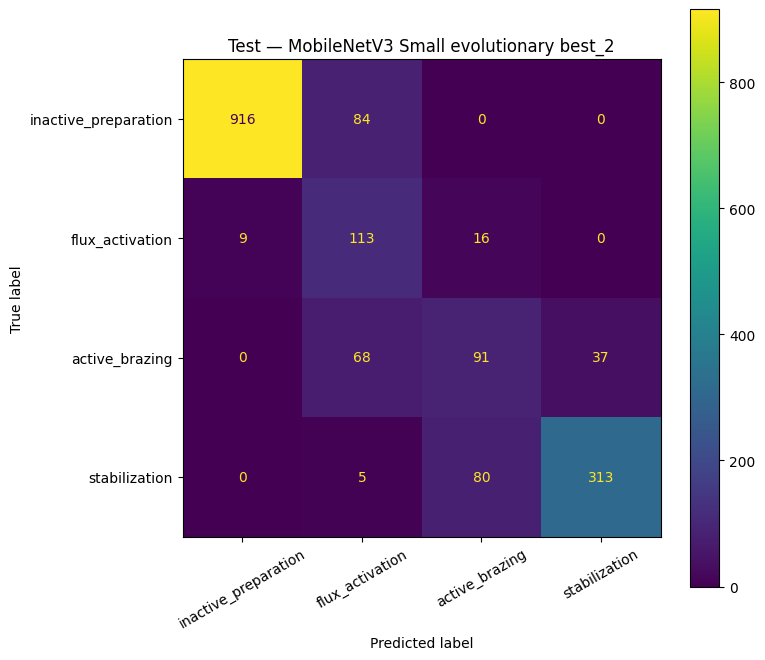

In [91]:
result_2, pred_2 = evaluate_best_candidate(
    model=best_model_2,
    test_loader=best_test_loader_2,
    candidate_config=best_candidate_config_2,
    checkpoint_path=best_checkpoint_2,
    candidate_name="best_2",
)

top_candidate_results.append(result_2)
top_candidate_predictions["best_2"] = pred_2

Test — MobileNetV3 Small evolutionary best_3
--------------------------------------------------------------------------------
accuracy:    0.9221
macro_f1:    0.8239
weighted_f1: 0.9140

                      precision    recall  f1-score   support

inactive_preparation     0.9794    1.0000    0.9896      1000
     flux_activation     0.7400    0.8043    0.7708       138
      active_brazing     0.8846    0.4694    0.6133       196
       stabilization     0.8621    0.9899    0.9216       398

            accuracy                         0.9221      1732
           macro avg     0.8665    0.8159    0.8239      1732
        weighted avg     0.9227    0.9221    0.9140      1732



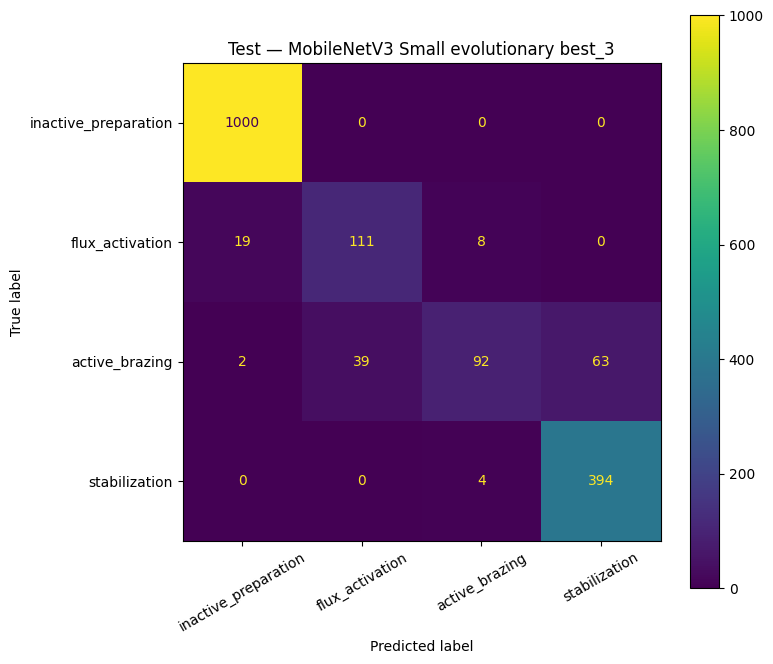

In [92]:
result_3, pred_3 = evaluate_best_candidate(
    model=best_model_3,
    test_loader=best_test_loader_3,
    candidate_config=best_candidate_config_3,
    checkpoint_path=best_checkpoint_3,
    candidate_name="best_3",
)

top_candidate_results.append(result_3)
top_candidate_predictions["best_3"] = pred_3

In [93]:
top_candidate_test_comparison_df = pd.DataFrame(top_candidate_results).sort_values(
    "macro_f1",
    ascending=False,
)

top_candidate_test_comparison_df

,candidate_name,image_size,lr,weight_decay,active_brazing_boost,augmentation,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint,predictions_path,metrics_path
2,best_3,128,0.0003,0.0003,1.2,low,0.922055,0.823853,0.913978,0.884615,0.469388,0.613333,models/checkpoints/mobilenet_evolutionary_sear...,reports/mobilenet_evolutionary_search/mobilene...,reports/mobilenet_evolutionary_search/mobilene...
0,best_1,224,0.0001,0.0003,1.2,low,0.882217,0.781997,0.880295,0.756303,0.459184,0.571429,models/checkpoints/mobilenet_evolutionary_sear...,reports/mobilenet_evolutionary_search/mobilene...,reports/mobilenet_evolutionary_search/mobilene...
1,best_2,192,0.0001,0.0003,1.0,medium,0.827367,0.704426,0.839696,0.486631,0.464286,0.475196,models/checkpoints/mobilenet_evolutionary_sear...,reports/mobilenet_evolutionary_search/mobilene...,reports/mobilenet_evolutionary_search/mobilene...


In [94]:
top_candidate_test_comparison_df.to_csv(
    REPORTS_DIR / "mobilenet_evo_top3_test_comparison.csv",
    index=False,
)

### error pairs

In [95]:
def get_error_pairs(pred_df: pd.DataFrame):
    errors_df = pred_df[pred_df["stage_id"] != pred_df["pred_stage_id"]].copy()

    return (
        errors_df
        .groupby(["stage_name", "pred_stage_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

In [96]:
for candidate_name, pred_df in top_candidate_predictions.items():
    print(f"Error pairs — {candidate_name}")
    display(get_error_pairs(pred_df).head(20))

Error pairs — best_1


,stage_name,pred_stage_name,count
2,active_brazing,stabilization,79
5,inactive_preparation,flux_activation,62
0,active_brazing,flux_activation,26
6,stabilization,active_brazing,23
4,flux_activation,inactive_preparation,7
3,flux_activation,active_brazing,6
1,active_brazing,inactive_preparation,1


Error pairs — best_2


,stage_name,pred_stage_name,count
4,inactive_preparation,flux_activation,84
5,stabilization,active_brazing,80
0,active_brazing,flux_activation,68
1,active_brazing,stabilization,37
2,flux_activation,active_brazing,16
3,flux_activation,inactive_preparation,9
6,stabilization,flux_activation,5


Error pairs — best_3


,stage_name,pred_stage_name,count
2,active_brazing,stabilization,63
0,active_brazing,flux_activation,39
4,flux_activation,inactive_preparation,19
3,flux_activation,active_brazing,8
5,stabilization,active_brazing,4
1,active_brazing,inactive_preparation,2


### timeline plots

In [97]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, run_name: str):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id} — {run_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_{run_name}_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

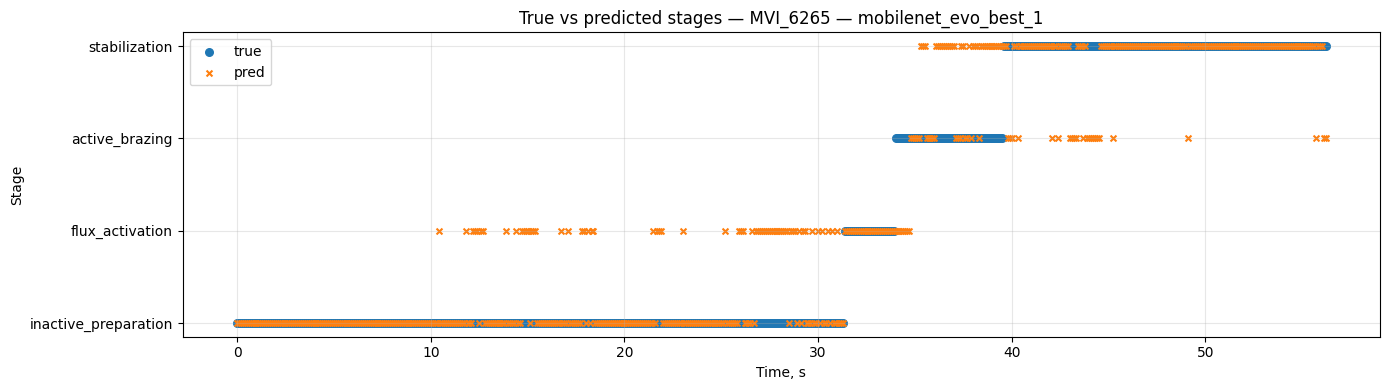

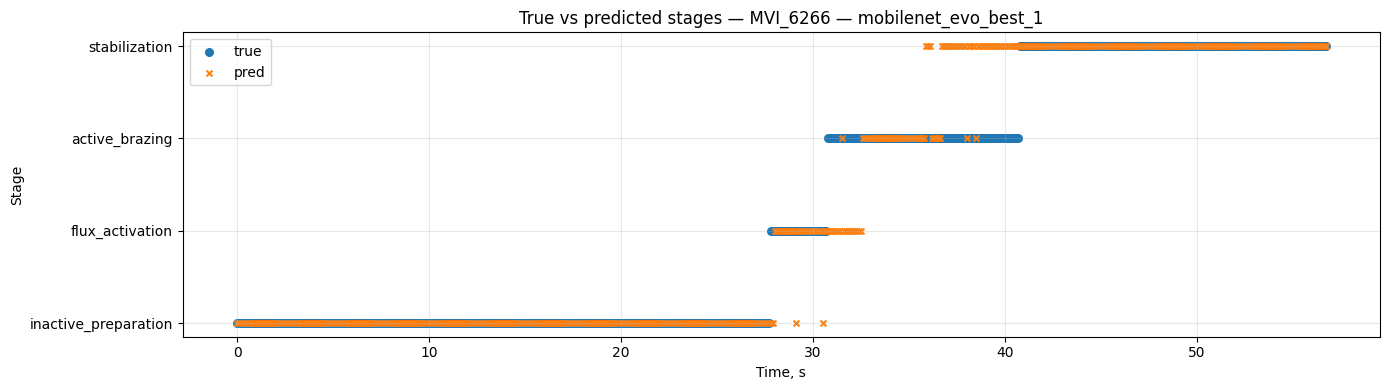

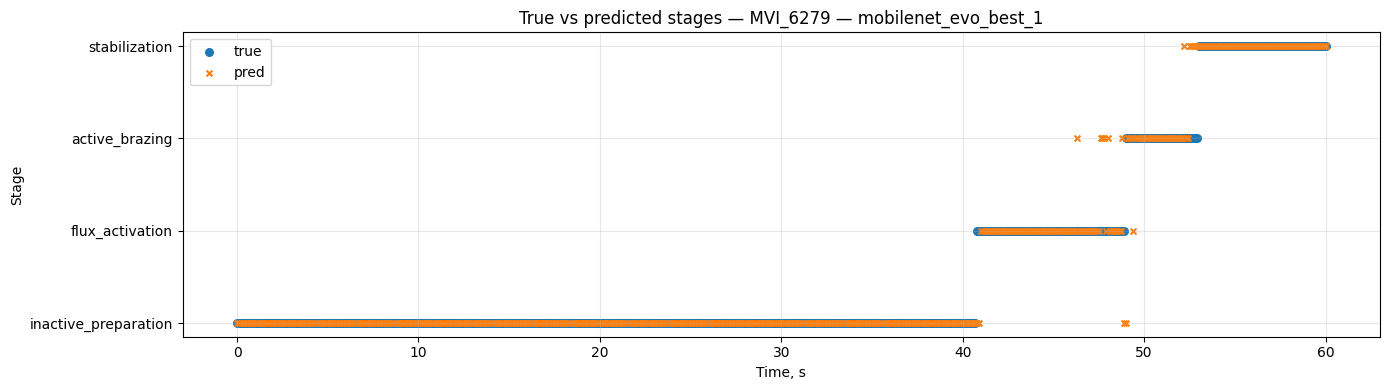

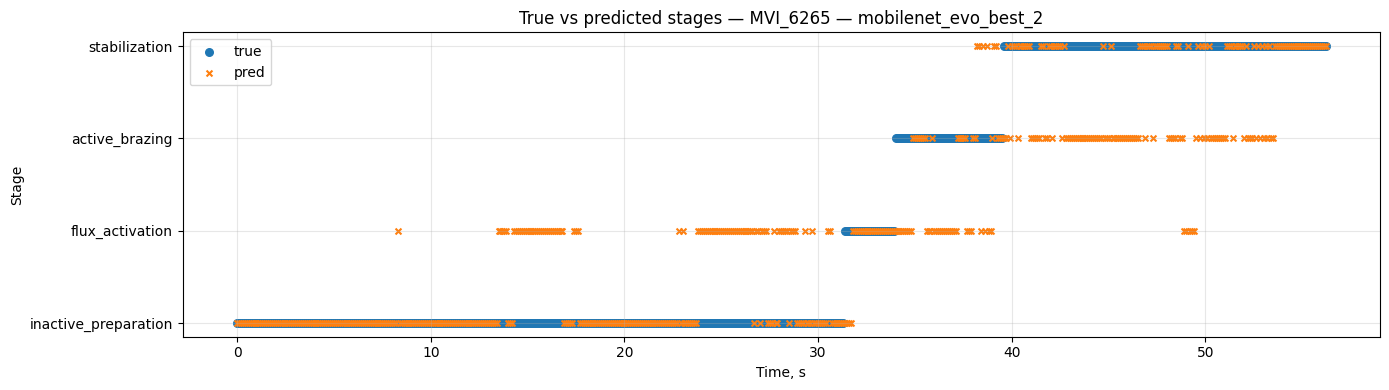

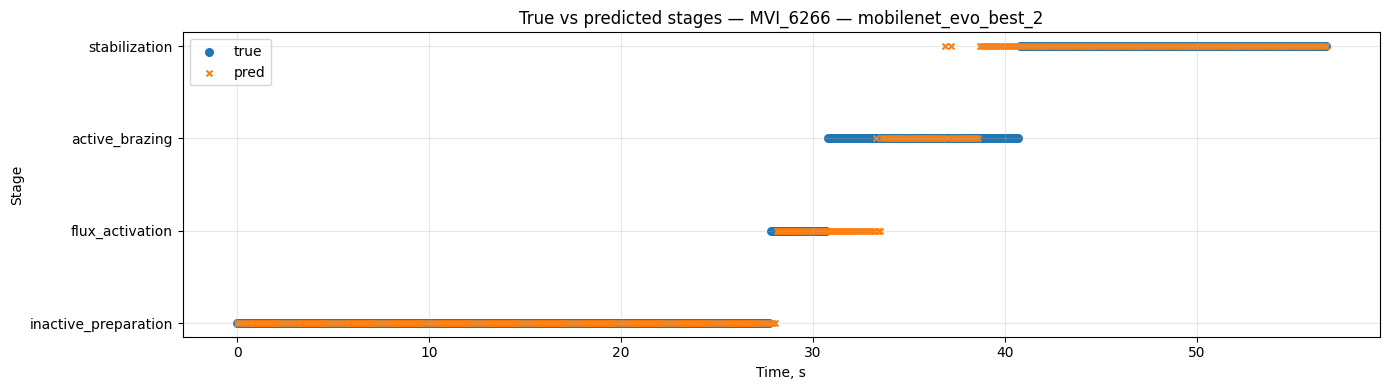

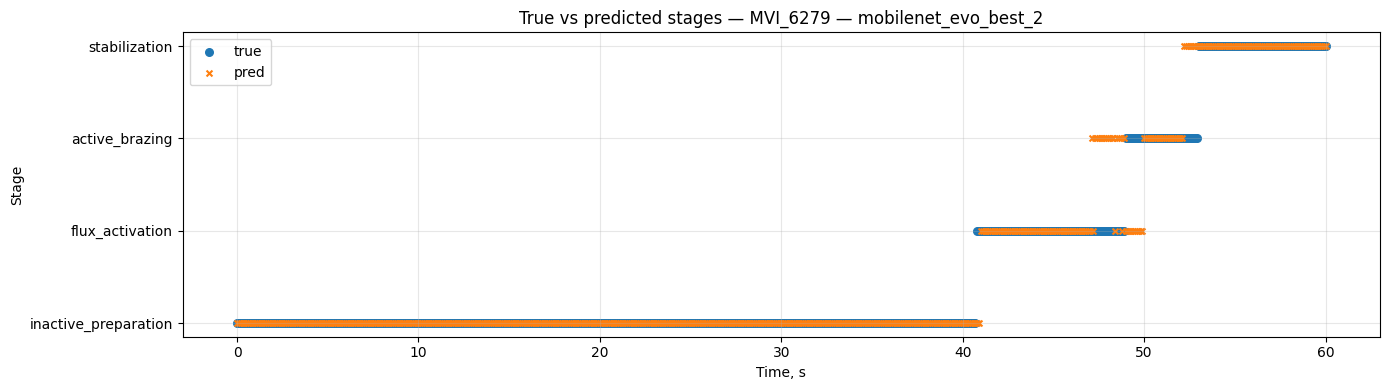

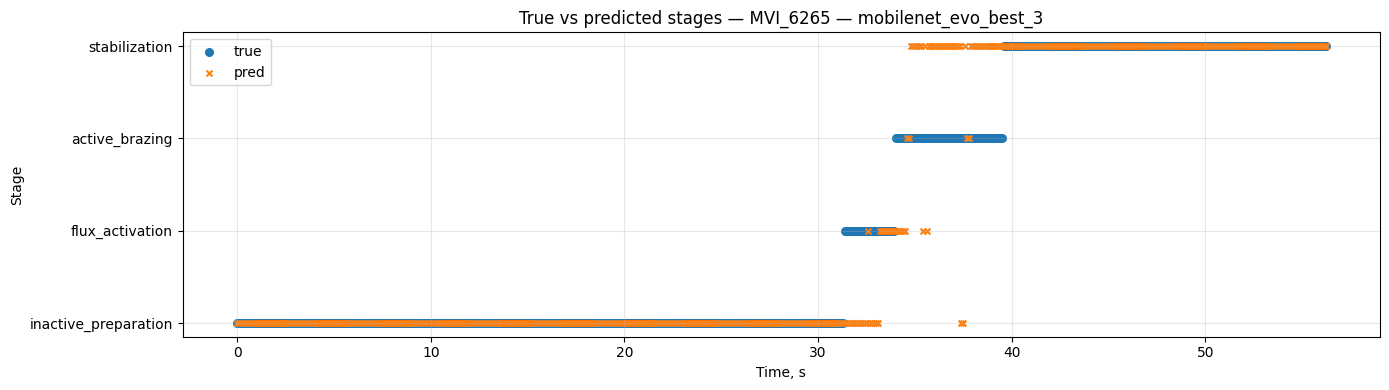

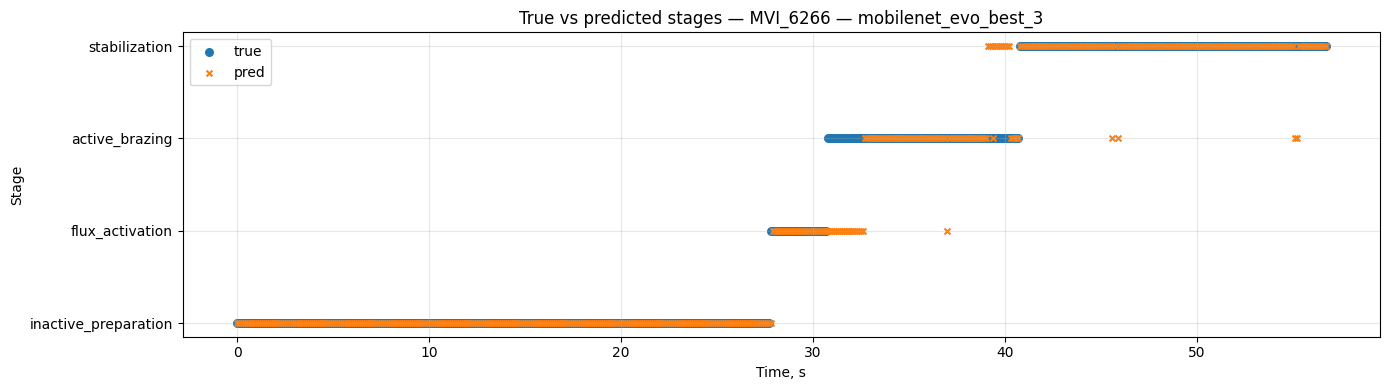

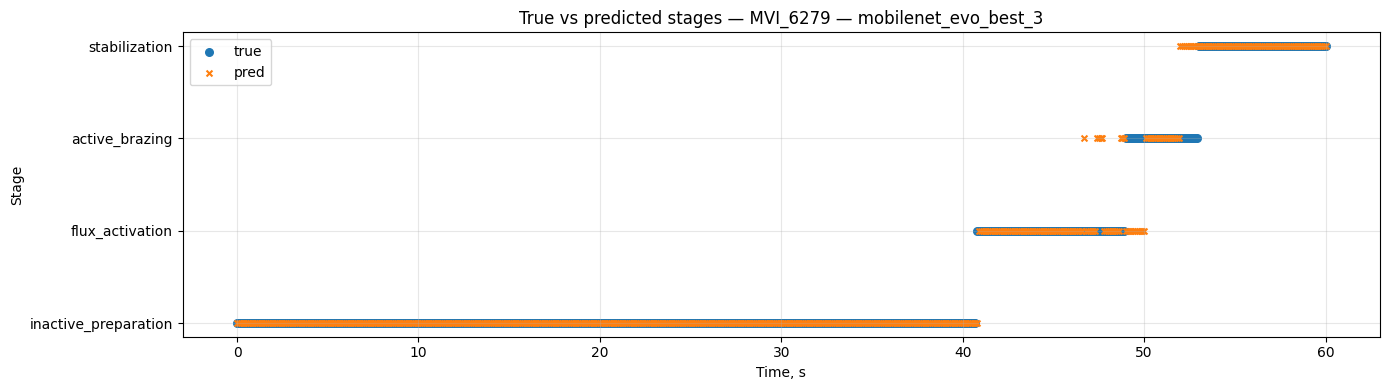

In [98]:
for candidate_name, pred_df in top_candidate_predictions.items():
    for video_id in sorted(pred_df["video_id"].unique()):
        plot_predictions_for_video(
            pred_df,
            video_id=video_id,
            run_name=f"mobilenet_evo_{candidate_name}",
        )

## best evo

In [99]:
mobilenet_005_checkpoint = (
    CHECKPOINTS_DIR / "mobilenet_evo_005_best.pt"
)

checkpoint_005 = torch.load(mobilenet_005_checkpoint, map_location=DEVICE)

checkpoint_005["run_name"], checkpoint_005["epoch"], checkpoint_005["val_macro_f1"], checkpoint_005.get("val_active_brazing_f1")

('mobilenet_evo_005', 8, 0.9274278441401353, 0.9104477611940298)

In [100]:
mobilenet_005_config = checkpoint_005.get("candidate", {})
mobilenet_005_config

{'run_name': 'mobilenet_evo_005',
 'image_size': 224,
 'lr': 0.0001,
 'weight_decay': 0.0003,
 'active_brazing_boost': 1.2,
 'augmentation': 'low'}

In [101]:
mobilenet_005_image_size = int(
    checkpoint_005.get(
        "image_size",
        mobilenet_005_config.get("image_size", 224),
    )
)

mobilenet_005_augmentation = mobilenet_005_config.get("augmentation", "low")

mobilenet_005_model = create_mobilenet_v3_small(
    num_classes=4,
    pretrained=False,
).to(DEVICE)

mobilenet_005_model.load_state_dict(checkpoint_005["model_state_dict"])
mobilenet_005_model.eval()

_, _, mobilenet_005_test_loader = make_dataloaders(
    image_size=mobilenet_005_image_size,
    augmentation=mobilenet_005_augmentation,
)

mobilenet_005_image_size, mobilenet_005_augmentation

(224, 'low')

Test — MobileNetV3 Small mobilenet_evo_005
--------------------------------------------------------------------------------
accuracy:    0.8649
macro_f1:    0.7284
weighted_f1: 0.8606

                      precision    recall  f1-score   support

inactive_preparation     0.9603    0.9920    0.9759      1000
     flux_activation     0.5549    0.6594    0.6026       138
      active_brazing     0.5743    0.4337    0.4942       196
       stabilization     0.8527    0.8291    0.8408       398

            accuracy                         0.8649      1732
           macro avg     0.7356    0.7286    0.7284      1732
        weighted avg     0.8596    0.8649    0.8606      1732



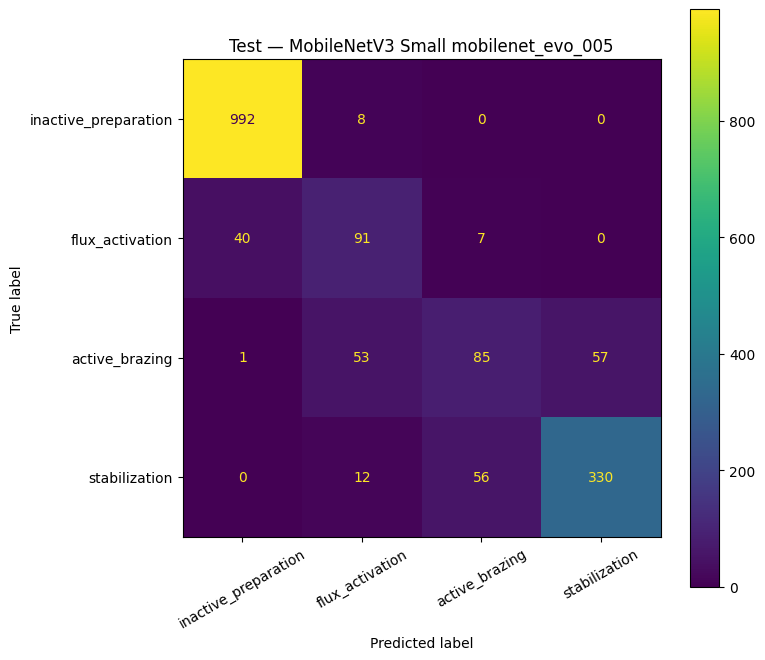

{'accuracy': 0.8648960739030023,
 'macro_f1': 0.7283742681224832,
 'weighted_f1': 0.8605934872964434,
 'active_brazing_precision': 0.5743243243243243,
 'active_brazing_recall': 0.4336734693877551,
 'active_brazing_f1': 0.4941860465116279,
 'confusion_matrix': [[992, 8, 0, 0],
  [40, 91, 7, 0],
  [1, 53, 85, 57],
  [0, 12, 56, 330]]}

In [102]:
mobilenet_005_pred_df = predict_loader(
    mobilenet_005_model,
    mobilenet_005_test_loader,
)

mobilenet_005_test_metrics = evaluate_predictions(
    mobilenet_005_pred_df,
    title="Test — MobileNetV3 Small mobilenet_evo_005",
)

mobilenet_005_test_metrics

In [103]:
mobilenet_005_pred_path = REPORTS_DIR / "mobilenet_evo_005_test_predictions.csv"
mobilenet_005_metrics_path = REPORTS_DIR / "mobilenet_evo_005_test_metrics.json"

mobilenet_005_pred_df.to_csv(mobilenet_005_pred_path, index=False)

with open(mobilenet_005_metrics_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "candidate_name": "mobilenet_evo_005",
            "candidate_config": mobilenet_005_config,
            "checkpoint": str(mobilenet_005_checkpoint),
            "test_metrics": mobilenet_005_test_metrics,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

mobilenet_005_pred_path, mobilenet_005_metrics_path

(PosixPath('reports/mobilenet_evolutionary_search/mobilenet_evo_005_test_predictions.csv'),
 PosixPath('reports/mobilenet_evolutionary_search/mobilenet_evo_005_test_metrics.json'))

In [104]:
print("Error pairs — mobilenet_evo_005")
get_error_pairs(mobilenet_005_pred_df).head(20)

Error pairs — mobilenet_evo_005


,stage_name,pred_stage_name,count
2,active_brazing,stabilization,57
6,stabilization,active_brazing,56
0,active_brazing,flux_activation,53
4,flux_activation,inactive_preparation,40
7,stabilization,flux_activation,12
5,inactive_preparation,flux_activation,8
3,flux_activation,active_brazing,7
1,active_brazing,inactive_preparation,1


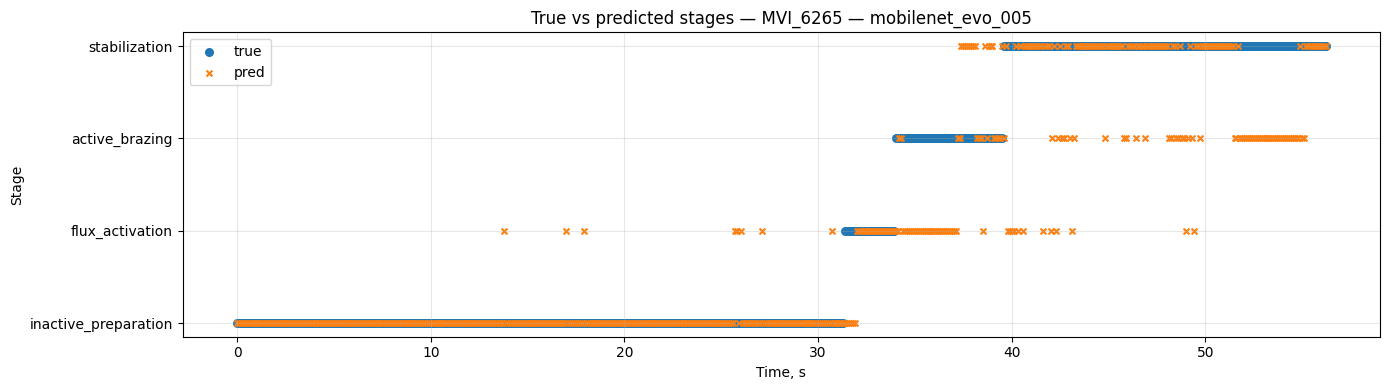

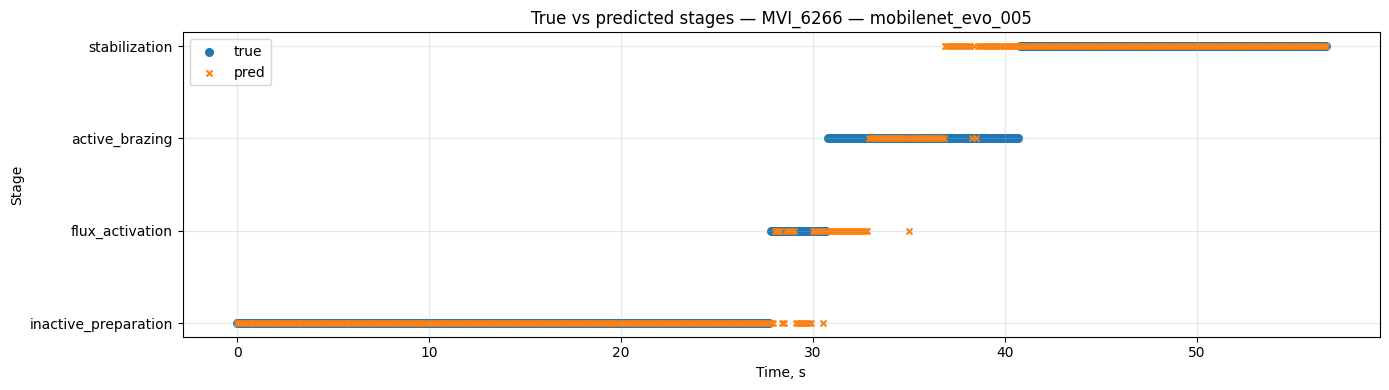

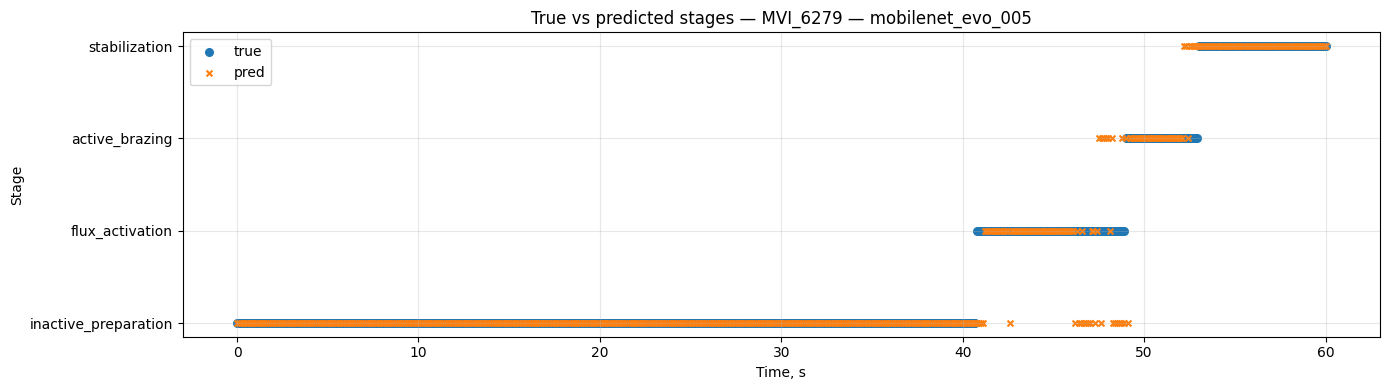

In [105]:
for video_id in sorted(mobilenet_005_pred_df["video_id"].unique()):
    plot_predictions_for_video(
        mobilenet_005_pred_df,
        video_id=video_id,
        run_name="mobilenet_evo_005",
    )

# results

In [74]:
CHECKPOINTS_DIR, DRIVE_CHECKPOINTS_DIR

(PosixPath('models/checkpoints/mobilenet_evolutionary_search'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Diploma/models/checkpoints/mobilenet_evolutionary_search'))

In [106]:
!cp -r "$CHECKPOINTS_DIR"/. "$DRIVE_CHECKPOINTS_DIR"/

В 10_mobilenet_evolutionary_search.ipynb мы сделали упрощённый эволюционный подбор гиперпараметров для MobileNetV3 Small как CPU-friendly альтернативы тяжёлой модели.

Проверялись параметры:

```text
image_size
learning rate
weight decay
active_brazing class boost
уровень аугментаций
```

Лучшие кандидаты показали, что для MobileNet важны:

```text
умеренный learning rate: 1e-4
умеренный active_brazing boost: около 1.0–1.2
low/medium augmentation
image_size 128–224 в зависимости от компромисса скорость/качество
```

По test лучший MobileNet-кандидат не идеально повторил validation, но дал рабочую CPU-friendly систему. Финальное демо на mobilenet_evo_best_finetuned_best получилось приемлемым: стадия активной пайки определяется с некоторым запаздыванием, но сигнал HOLD TEMPERATURE формируется корректно, а CPU-инференс проходит по ограничению.

MobileNetV3 Small после подбора гиперпараметров может использоваться как CPU-friendly вариант системы.
ResNet18 остаётся более качественной моделью для GPU/основного исследования.
MobileNetV3 Small — практичный вариант для CPU-демо и внедрения без GPU.